# Bluesky Post Fetching Pipeline

This notebook fetches raw Bluesky posts first, then builds a clean English-only dataset in separate, auditable steps.

## Imports

In [1]:
import os
import sys
import pandas as pd
import utils_preprocessing as up
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from datetime import datetime, timezone

## Configuration

In [16]:
load_dotenv()

BSKY_HANDLE = os.getenv("BSKY_HANDLE")
BSKY_PASSWORD = os.getenv("BSKY_PASSWORD")

SEARCH_QUERIES = [
    "AI",
    "Artificial Intelligence",
    "AI Bubble",
    "ChatGPT",
    "Gemini",
]
START_DATE = datetime(2022, 1, 1, tzinfo=timezone.utc)
END_DATE = datetime(2025, 12, 31, tzinfo=timezone.utc)
POSTS_PER_MONTH = 100
REQUEST_SLEEP_SECONDS = 0.5
MAX_TOKENS = 500

RAW_OUTPUT_PATH = "../data/v2/raw_posts_bsky.csv"
CLEAN_OUTPUT_PATH = "../data/v2/clean_posts_bsky.csv"

## Run Pipeline

In [17]:
client = up.connect_bsky(BSKY_HANDLE, BSKY_PASSWORD)

raw_bsky_df = up.fetch_raw_bsky_posts(
    client=client,
    search_queries=SEARCH_QUERIES,
    start_date=START_DATE,
    end_date=END_DATE,
    posts_per_month=POSTS_PER_MONTH,
    sleep_seconds=REQUEST_SLEEP_SECONDS,
)

Connected to Bluesky successfully!
Starting raw Bluesky fetch from 2022-01-01 to 2025-12-31...
Processing Bluesky posts for 2022-01...
Finished 2022-01. Raw rows collected so far: 115
Processing Bluesky posts for 2022-02...
Finished 2022-02. Raw rows collected so far: 241
Processing Bluesky posts for 2022-03...
Finished 2022-03. Raw rows collected so far: 367
Processing Bluesky posts for 2022-04...
Finished 2022-04. Raw rows collected so far: 490
Processing Bluesky posts for 2022-05...
Finished 2022-05. Raw rows collected so far: 615
Processing Bluesky posts for 2022-06...
Finished 2022-06. Raw rows collected so far: 755
Processing Bluesky posts for 2022-07...
Finished 2022-07. Raw rows collected so far: 884
Processing Bluesky posts for 2022-08...
Finished 2022-08. Raw rows collected so far: 1,025
Processing Bluesky posts for 2022-09...
Finished 2022-09. Raw rows collected so far: 1,147
Processing Bluesky posts for 2022-10...
Finished 2022-10. Raw rows collected so far: 1,273
Processin

In [18]:
# # get data from months that had api errors
# additional_data = up.fetch_raw_bsky_posts(
#     client=client,
#     search_queries=SEARCH_QUERIES,
#     start_date=datetime(2023, 6,1, tzinfo=timezone.utc),
#     end_date=datetime(2023, 10,31, tzinfo=timezone.utc),
#     posts_per_month=POSTS_PER_MONTH,
#     sleep_seconds=REQUEST_SLEEP_SECONDS,
# )

In [19]:
# Combine with original raw data
# raw_bsky_df = pd.concat([raw_bsky_df, additional_data], ignore_index=True)                        
up.save_dataset(raw_bsky_df, RAW_OUTPUT_PATH)
display(raw_bsky_df.head())

Saved 17,270 rows to ../data/v2/raw_posts_bsky.csv


,Month,Date,Query,Post_ID,Text,Likes,Reposts,Replies,Weight
0,2022-01-01,2022-01-04 03:55:16+00:00,AI,at://did:plc:uxkyer4ru2tkxirh4ajyl3a4/app.bsky...,the #Data Science Daily is out! #bigdata #data...,0,0,0,1
1,2022-01-01,2022-01-28 21:49:14+00:00,AI,at://did:plc:2woydvpfmaxkalusdykip5pd/app.bsky...,AI-teknik blåser liv i filmklipp från 1900-tal...,0,0,0,1
2,2022-01-01,2022-01-20 08:48:01+00:00,AI,at://did:plc:zopuy2ivmbsygcb27y7z5bhn/app.bsky...,"Save the Date: May 09-11, 2022 - and check out...",0,0,0,1
3,2022-01-01,2022-01-13 14:50:33+00:00,AI,at://did:plc:xy5jxwppps74gfzj5h7tpibz/app.bsky...,This AI-inserted referral-money-making panel u...,0,0,0,1
4,2022-01-01,2022-01-30 13:11:45+00:00,AI,at://did:plc:bql47h7w7rh7dt2kjzx2vcoy/app.bsky...,Eu esqueço o quanto tênis é bom\nAí aparece es...,0,0,0,1


In [20]:
def build_clean_bsky_dataset(raw_df, max_tokens=500):
    """Run the full cleaning pipeline on a raw Bluesky DataFrame."""
    cleaned = up.drop_empty_rows_and_duplicates(raw_df, text_column="Text")
    cleaned = up.normalize_comment_text(cleaned, source_column="Text", output_column="Clean_Comment")
    cleaned = up.keep_english_comments(cleaned, text_column="Clean_Comment", language_column="Language")
    cleaned = up.truncate_comment_tokens(cleaned, text_column="Clean_Comment", max_tokens=max_tokens)

    print(f"Final clean dataset has {len(cleaned):,} rows.")
    return cleaned

In [48]:
raw_bsky_df = pd.read_csv(RAW_OUTPUT_PATH)
clean_bsky_df = build_clean_bsky_dataset(raw_bsky_df, max_tokens=MAX_TOKENS)

OIOIOIOIOIOI
DUPLICATE SUBSET: ['Post_ID', 'Text']
Dropped 49 empty text rows.
Dropped 400 duplicate rows using ['Post_ID', 'Text'].
Dropped 69 rows that were empty after text normalization.
Dropped 4,792 non-English or undetected rows.
Final clean dataset has 11,960 rows.


In [51]:
up.save_dataset(clean_bsky_df, CLEAN_OUTPUT_PATH)
display(clean_bsky_df.head())

Saved 11,960 rows to ../data/v2/clean_posts_bsky.csv


,Month,Date,Query,Post_ID,Text,Likes,Reposts,Replies,Weight,Clean_Comment,Language,Original_Token_Count,Final_Token_Count
0,2022-01-01,2022-01-04 03:55:16+00:00,AI,at://did:plc:uxkyer4ru2tkxirh4ajyl3a4/app.bsky...,the #Data Science Daily is out! #bigdata #data...,0,0,0,1,the #data science daily is out! #bigdata #data...,en,13,13
1,2022-01-01,2022-01-20 08:48:01+00:00,AI,at://did:plc:zopuy2ivmbsygcb27y7z5bhn/app.bsky...,"Save the Date: May 09-11, 2022 - and check out...",0,0,0,1,"save the date: may 09-11, 2022 - and check out...",en,23,23
2,2022-01-01,2022-01-13 14:50:33+00:00,AI,at://did:plc:xy5jxwppps74gfzj5h7tpibz/app.bsky...,This AI-inserted referral-money-making panel u...,0,0,0,1,this ai-inserted referral-money-making panel u...,en,17,17
3,2022-01-01,2022-01-03 01:21:24+00:00,AI,at://did:plc:hmtimeybcvsw23mfeqa6g7fs/app.bsky...,I've just updated my webpage with some great a...,0,0,0,1,i've just updated my webpage with some great a...,en,17,17
4,2022-01-01,2022-01-09 18:17:59+00:00,AI,at://did:plc:eszqbenruwgseayrkcijp62t/app.bsky...,Interesting piece by @lfspinney: Are we witnes...,0,0,0,1,interesting piece by : are we witnessing the d...,en,14,14


In [52]:
# Check proportion of empty dates in raw dataset
empty_dates = raw_bsky_df["Date"].isna().sum()
print(f"Proportion of empty dates in raw dataset: {empty_dates / len(raw_bsky_df):.2%}")

# Check proportion of empty dates in clean dataset
empty_dates_clean = clean_bsky_df["Date"].isna().sum()
print(f"Proportion of empty dates in clean dataset: {empty_dates_clean / len(clean_bsky_df):.2%}")

Proportion of empty dates in raw dataset: 0.00%
Proportion of empty dates in clean dataset: 0.00%


In [57]:
# Remove all gemini posts before MAY 2023
clean_bsky_df["Date"] = pd.to_datetime(clean_bsky_df["Date"], utc=True, format="mixed")
clean_bsky_df = clean_bsky_df[~((clean_bsky_df["Query"] == "Gemini") & (clean_bsky_df["Date"] < pd.Timestamp("2023-05-01", tz="UTC")))]

In [ ]:
# Check proportion of empty dates in clean dataset
empty_dates_clean = clean_bsky_df["Date"].isna().sum()
print(f"Proportion of empty dates in clean dataset: {empty_dates_clean / len(clean_bsky_df):.2%}")

Proportion of empty dates in clean dataset: 0.00%


In [60]:
up.save_dataset(clean_bsky_df, CLEAN_OUTPUT_PATH)
display(clean_bsky_df.head())

Saved 11,760 rows to ../data/v2/clean_posts_bsky.csv


,Month,Date,Query,Post_ID,Text,Likes,Reposts,Replies,Weight,Clean_Comment,Language,Original_Token_Count,Final_Token_Count
0,2022-01-01,2022-01-04 03:55:16+00:00,AI,at://did:plc:uxkyer4ru2tkxirh4ajyl3a4/app.bsky...,the #Data Science Daily is out! #bigdata #data...,0,0,0,1,the #data science daily is out! #bigdata #data...,en,13,13
1,2022-01-01,2022-01-20 08:48:01+00:00,AI,at://did:plc:zopuy2ivmbsygcb27y7z5bhn/app.bsky...,"Save the Date: May 09-11, 2022 - and check out...",0,0,0,1,"save the date: may 09-11, 2022 - and check out...",en,23,23
2,2022-01-01,2022-01-13 14:50:33+00:00,AI,at://did:plc:xy5jxwppps74gfzj5h7tpibz/app.bsky...,This AI-inserted referral-money-making panel u...,0,0,0,1,this ai-inserted referral-money-making panel u...,en,17,17
3,2022-01-01,2022-01-03 01:21:24+00:00,AI,at://did:plc:hmtimeybcvsw23mfeqa6g7fs/app.bsky...,I've just updated my webpage with some great a...,0,0,0,1,i've just updated my webpage with some great a...,en,17,17
4,2022-01-01,2022-01-09 18:17:59+00:00,AI,at://did:plc:eszqbenruwgseayrkcijp62t/app.bsky...,Interesting piece by @lfspinney: Are we witnes...,0,0,0,1,interesting piece by : are we witnessing the d...,en,14,14


## Quick Checks

In [62]:
print("Raw rows by query:")
display(raw_bsky_df["Query"].value_counts())

print("Clean rows by query:")
display(clean_bsky_df["Query"].value_counts())

print("Maximum final token count:", clean_bsky_df["Final_Token_Count"].max())

Raw rows by query:


Query
AI                         4401
Artificial Intelligence    3551
ChatGPT                    3490
Gemini                     3200
AI Bubble                  2628
Name: count, dtype: int64

Clean rows by query:


Query
Artificial Intelligence    3221
AI Bubble                  2447
AI                         2208
ChatGPT                    2036
Gemini                     1848
Name: count, dtype: int64

Maximum final token count: 64


In [63]:
print("Total number of rows in the clean dataset:", len(clean_bsky_df))

Total number of rows in the clean dataset: 11760


/tmp/ipykernel_14121/2853982623.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  clean_bsky_df["YearMonth"] = clean_bsky_df["Date"].dt.to_period("M")


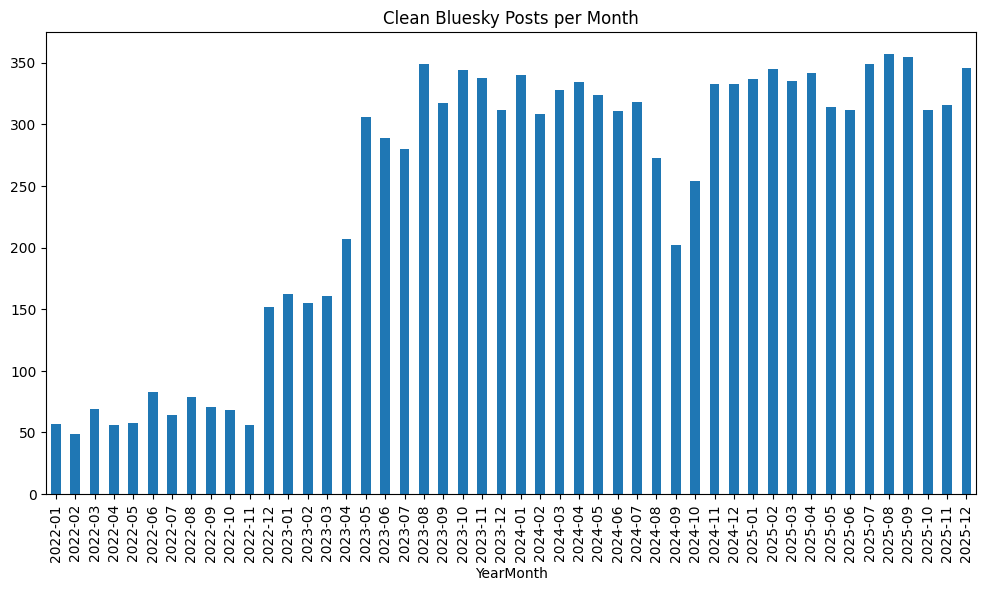

In [64]:
# Plot histogram of data per month in the clean dataset
clean_bsky_df["Date"] = pd.to_datetime(
    clean_bsky_df["Date"],
    utc=True
)
clean_bsky_df["YearMonth"] = clean_bsky_df["Date"].dt.to_period("M")
monthly_counts = clean_bsky_df.groupby("YearMonth").size()
monthly_counts.plot(kind="bar", figsize=(12, 6), title="Clean Bluesky Posts per Month")
# Save plot
plt.savefig("../data/v2/plots/bsky_posts_per_month.png")
plt.show()

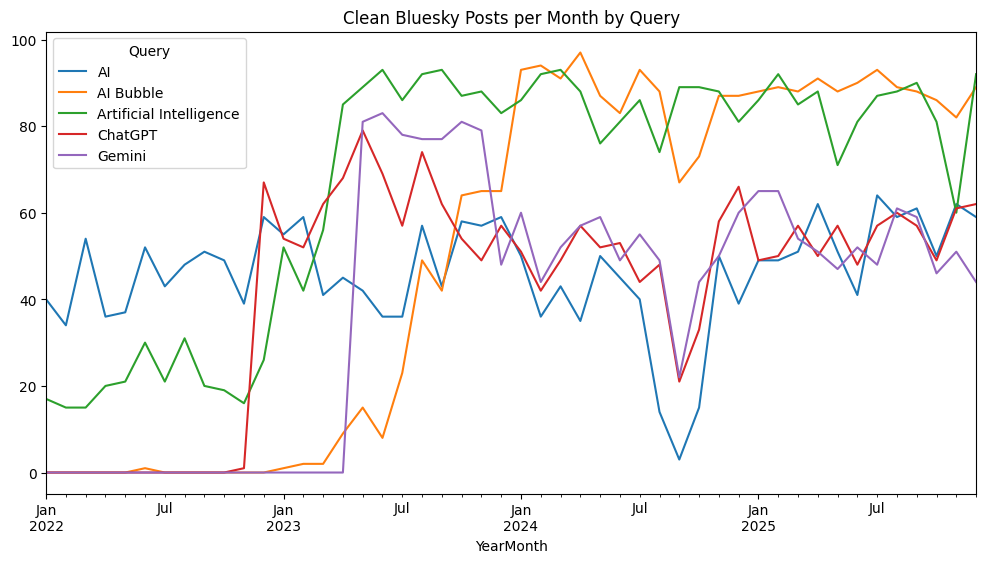

In [66]:
#Plot posts per month per query in the clean dataset
query_monthly_counts = clean_bsky_df.groupby(["YearMonth", "Query"]).size().unstack(fill_value=0)
query_monthly_counts.plot(kind="line", stacked=False, figsize=(12, 6), title="Clean Bluesky Posts per Month by Query")
# Save plot
plt.savefig("../data/v2/plots/bsky_posts_per_month_by_query.png")
plt.show()